<a href="https://colab.research.google.com/github/KhytsenkoIgor/python-data-analysis-tasks/blob/main/HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [3]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [4]:
df['month_year'] = df.index.to_period('M')          # перетворюємо дату в формат рік-місяць
df['month_year'] = df.month_year.astype(str)        # переводимо значення Period у текстовий формат

In [5]:
df['month_year'].head()

,month_year
datetime,
2011-01-01 00:00:00,2011-01
2011-01-01 01:00:00,2011-01
2011-01-01 02:00:00,2011-01
2011-01-01 03:00:00,2011-01
2011-01-01 04:00:00,2011-01


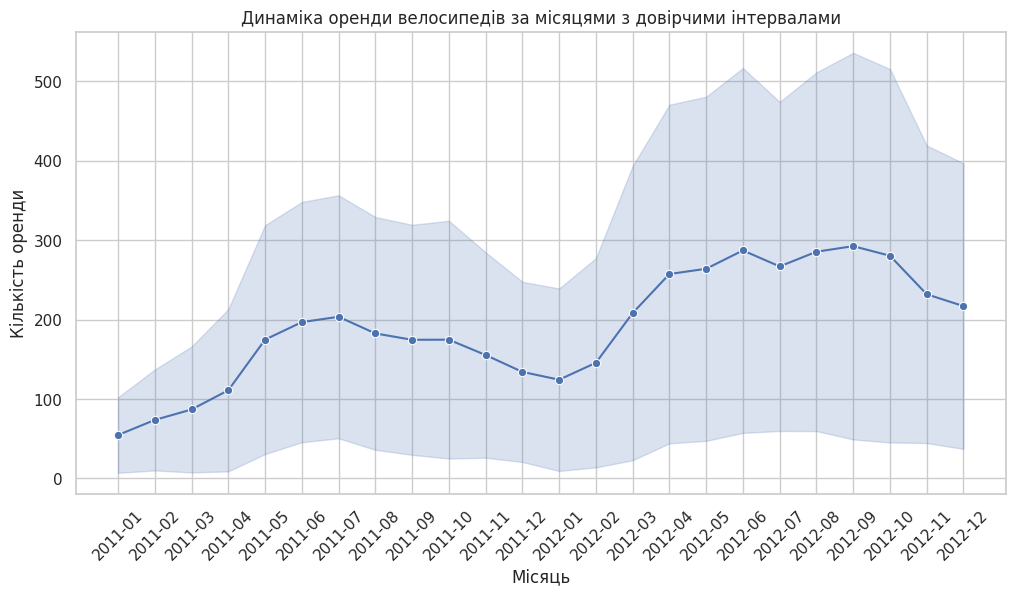

In [6]:
sns.set_theme(
    style='whitegrid',
    rc={'figure.figsize': (12, 6)}          # розмір графіка
)

ax = sns.lineplot(
    data=df,                                # наш датафрейм
    x='month_year',                         # місяць і рік по осі X
    y='count',                              # кількість оренд по осі Y
    errorbar='sd',                          # ±1 стандартне відхилення
    marker='o'                              # маркери на лінії
)

ax.set(
    title='Динаміка оренди велосипедів за місяцями з довірчими інтервалами',
    xlabel='Місяць',
    ylabel='Кількість оренди'
)

ax.tick_params(axis='x', labelrotation=45);       # нахил підписів місяців на 45°

**Відповідь:**


*  Найбільший розкид даних спостерігається у вересні (9) 2012 року. Загалом підвищена варіативність характерна для періоду з квітня (4) до жовтня (10) 2012 року. Це означає, що в ці місяці кількість оренд у різні дні та години значно відрізнялася від середнього значення.




## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

**1. Гістограма через Pandas**

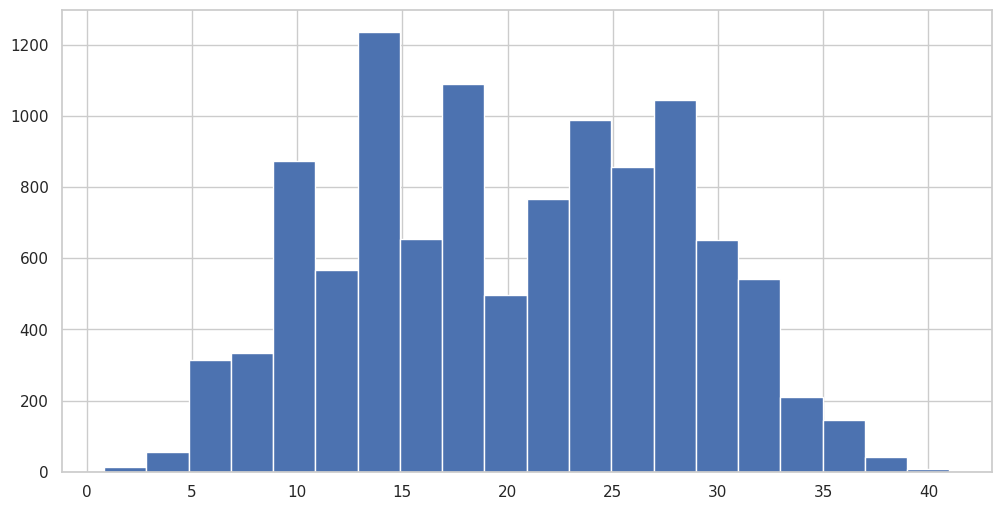

In [7]:
df['temp'].hist(
    bins=20                           # кількість інтервалів гістограми
);

2. **Гістограма через Seaborn**

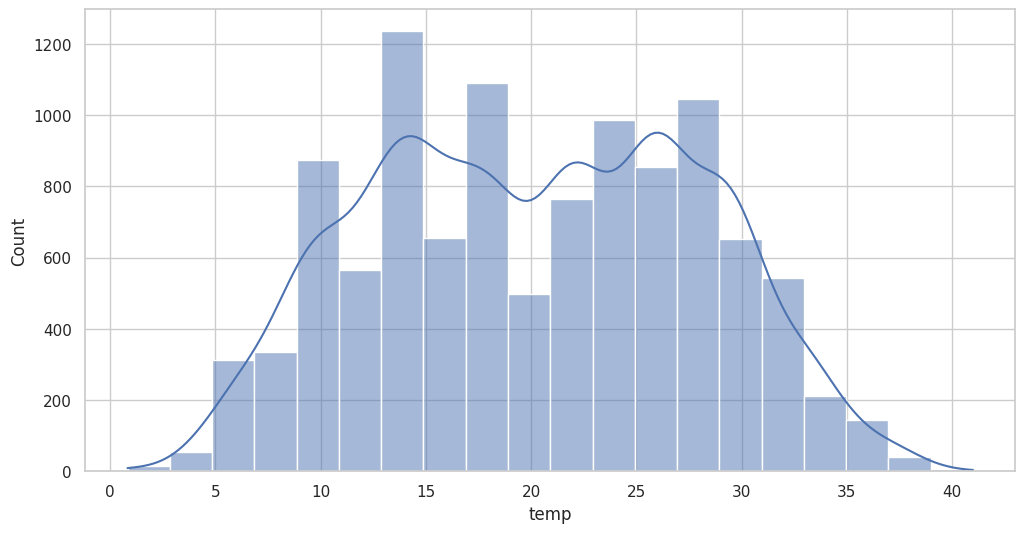

In [8]:
sns.histplot(
    data=df,                          # наш датафрейм
    x='temp',                         # температура по осі X
    bins=20,                          # така сама кількість бінів, як у Pandas
    kde=True                          # додаємо криву щільності розподілу
);

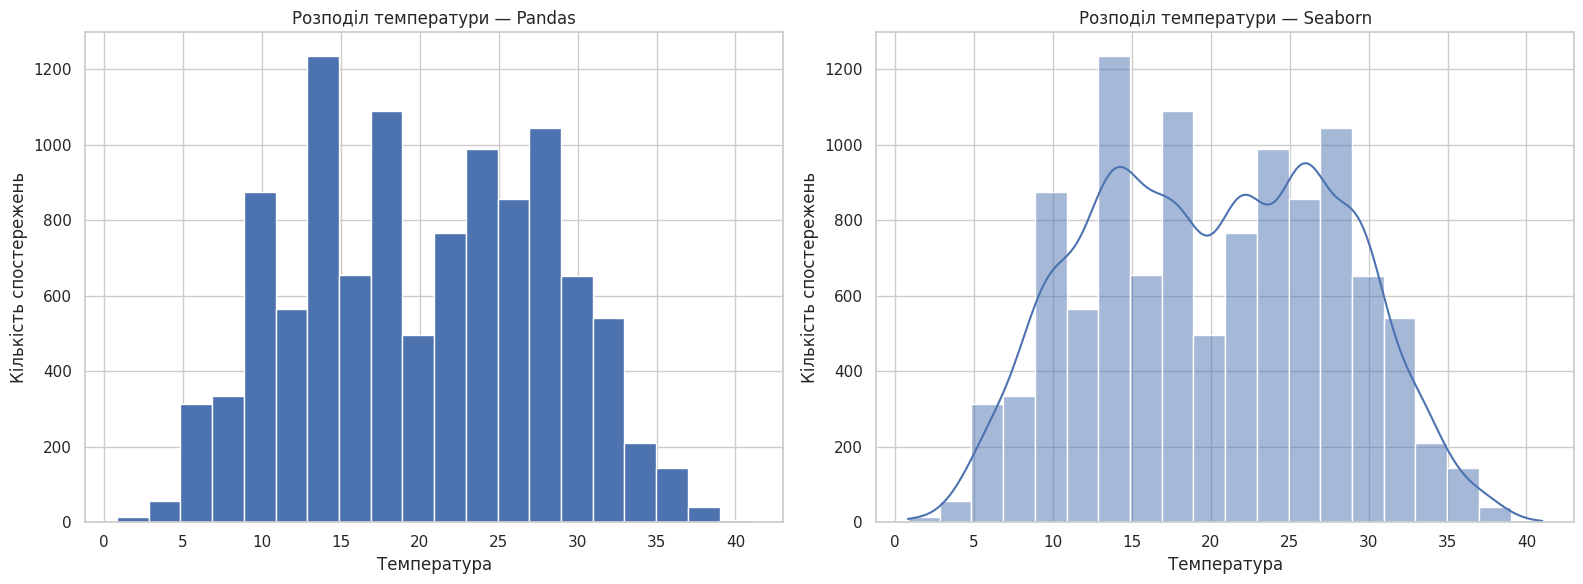

In [9]:
# Створюємо одну фігуру з двома графіками
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Гістограма через Pandas
df['temp'].hist(
    bins=20,                           # кількість бінів
    ax=axes[0]                         # перший графік
)

axes[0].set(
    title='Розподіл температури — Pandas',
    xlabel='Температура',
    ylabel='Кількість спостережень'
)

# 2. Гістограма через Seaborn
sns.histplot(
    data=df,                           # наш датафрейм
    x='temp',                          # температура
    bins=20,                           # така сама кількість бінів
    kde=True,                          # додаємо KDE-криву
    ax=axes[1]                         # другий графік
)

axes[1].set(
    title='Розподіл температури — Seaborn',
    xlabel='Температура',
    ylabel='Кількість спостережень'
)

plt.tight_layout();

**Відповідь:**


1.   *Яка візуальна різниця між Pandas та Seaborn гістограмами?*


*   Гістограма в Pandas у базовому варіанті показує розподіл даних за допомогою стовпців видно скільки значень потрапило в кожний інтервал. Seaborn також показує стовпці гістограми, але має більш виразне стандартне оформлення та орієнтований саме на статистичні візуалізації. Крім того, до гістограми Seaborn зручно додавати графік щільності розподілу. У лекції Seaborn описується як бібліотека зі зручнішим інтерфейсом для статистичних графіків і приємнішим стандартним стилем.


2.   *Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?*


*   Ця плавна лінія називається KDE (Kernel Density Estimate) - оцінка щільності розподілу. Вона показує згладжену форму розподілу даних і допомагає краще побачити, де значення концентруються найбільше, де знаходяться піки та як змінюється щільність. Простими словами гістограма показує розподіл стовпцями, а KDE  той самий характер розподілу у вигляді плавної лінії.






## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [ ]:
# Назви погодних умов відповідно до опису датасету
weather_names = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_name'] = df['weather'].map(weather_names)    # замінюємо коди погоди назвами

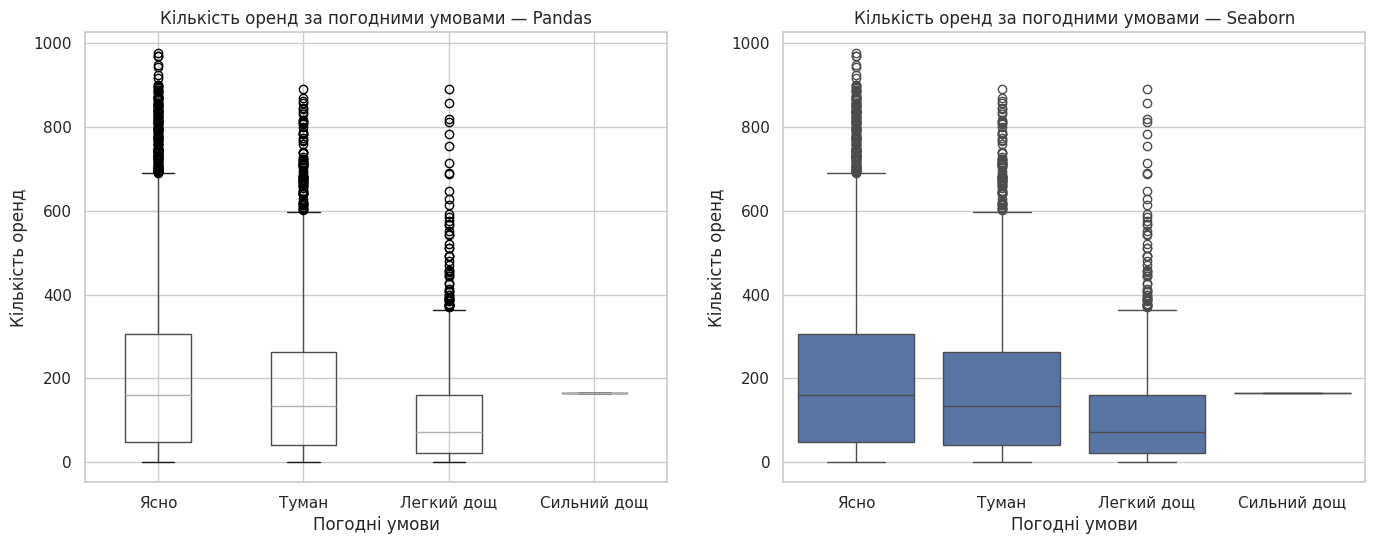

In [ ]:
# Встановлюємо однаковий порядок погодних умов для обох графіків
weather_order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

# Робимо колонку впорядкованою категорією
df['weather_name'] = pd.Categorical(
    df['weather_name'],
    categories=weather_order,
    ordered=True
)

# Створюємо одну фігуру з двома графіками
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Box plot через Pandas
df.boxplot(
    column='count',                    # кількість погодинних оренд
    by='weather_name',                 # групування за погодними умовами
    ax=axes[0]                         # перший графік
)

axes[0].set(
    title='Кількість оренд за погодними умовами — Pandas',
    xlabel='Погодні умови',
    ylabel='Кількість оренд'
)

# 2. Box plot через Seaborn
sns.boxplot(
    data=df,                           # наш датафрейм
    x='weather_name',                  # погодні умови
    y='count',                         # кількість оренд
    order=weather_order,               # однаковий порядок категорій
    ax=axes[1]                         # другий графік
)

axes[1].set(
    title='Кількість оренд за погодними умовами — Seaborn',
    xlabel='Погодні умови',
    ylabel='Кількість оренд'
)

fig.suptitle('');

**Відповідь:**


*   Візуально Pandas і Seaborn box plot показують практично однаковий розподіл даних: медіану, квартилі, «вуса» та викиди для кожного типу погоди. Основна різниця полягає в оформленні, Seaborn виглядає більш виразно та сучасно, оскільки за замовчуванням використовує кольорове заповнення коробок і приємніше стилізує графік. У Pandas box plot має простіше стандартне оформлення  коробки переважно білі, але сама статистична інформація залишається однаковою. Тобто різниця здебільшого в стилі візуалізації а не в результатах аналізу.




<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


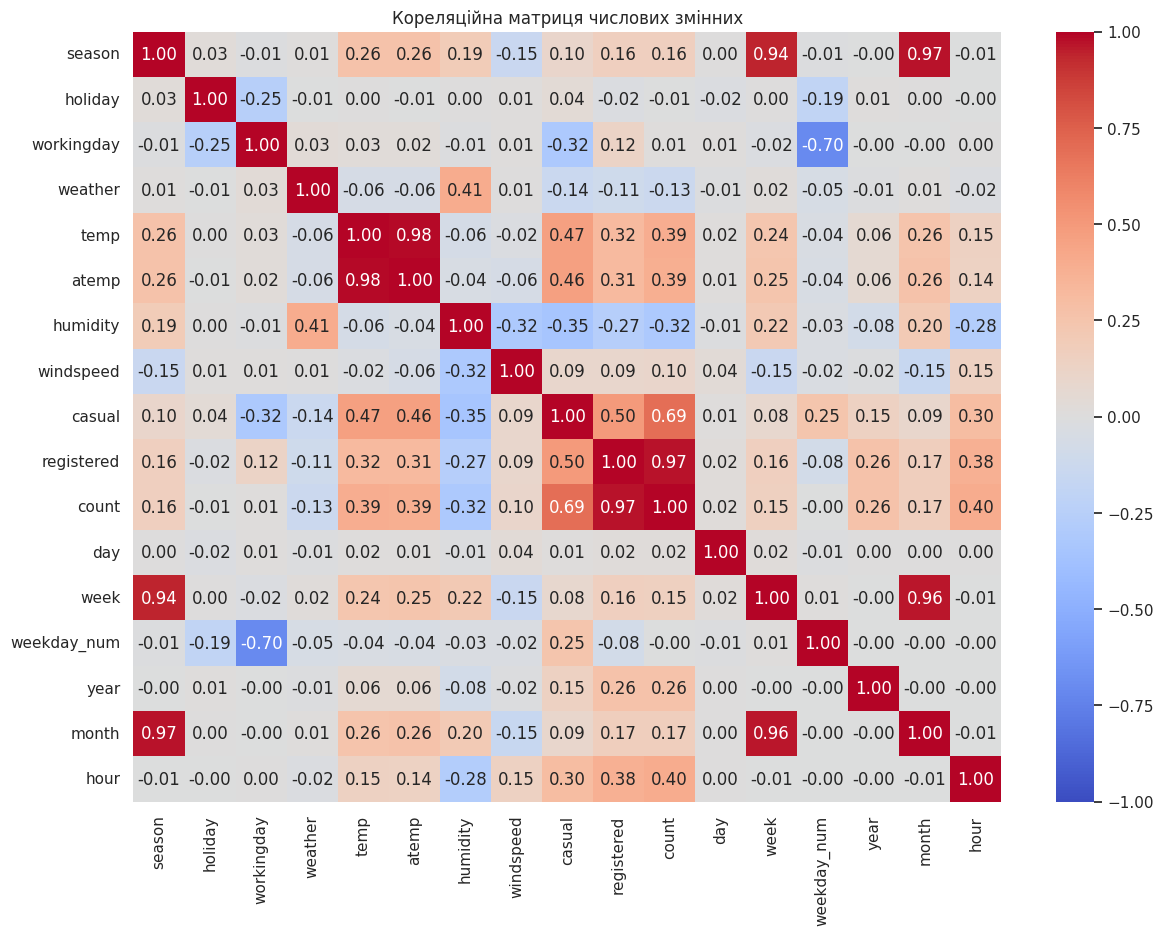

In [10]:
# Розраховуємо кореляцію між усіма числовими змінними
corr_matrix = df.corr(numeric_only=True)

# Встановлюємо розмір та стиль графіка
sns.set_theme(
    style='white',
    rc={'figure.figsize': (14, 10)}
)

# Будуємо heatmap кореляційної матриці
ax = sns.heatmap(
    corr_matrix,                       # кореляційна матриця
    annot=True,                        # показуємо значення кореляції в клітинках
    fmt='.2f',                         # округлення до 2 знаків
    cmap='coolwarm',                   # колір залежить від значення кореляції
    vmin=-1,                           # мінімальне можливе значення кореляції
    vmax=1                             # максимальне можливе значення кореляції
)

ax.set(
    title='Кореляційна матриця числових змінних'
);

**Відповідь:**
1. *Які змінні найсильніше корелюють з загальною кількістю оренди (count)?*


*   Найсильніша позитивна кореляція з count спостерігається у registered  0,97 та casual  0,69. Це логічно, оскільки загальна кількість оренд count фактично формується з оренд зареєстрованих і випадкових користувачів. Серед інших показників помітний позитивний зв’язок мають hour  0,40, а також temp і atemp  по 0,39, тобто кількість оренд певною мірою пов’язана з часом доби та температурою.



2. *Яка кореляція між temp та atemp? Чому?*


*   Між temp та atemp спостерігається дуже сильна позитивна кореляція 0,98. Це означає, що зі зростанням фактичної температури майже пропорційно зростає і температура, яка відчувається. Такий високий зв’язок закономірний, оскільки atemp безпосередньо пов’язана з реальною температурою, хоча додатково може враховувати інші погодні фактори.



3. *Які змінні мають негативну кореляцію?*


*   Для count найбільш помітна негативна кореляція спостерігається з humidity  -0,32 та weather  -0,13. Це означає що зі зростанням вологості та погіршенням погодних умов кількість оренд має тенденцію до зниження. Також у матриці видно інші негативні зв’язки, наприклад між humidity і casual -0,35, між humidity і registered -0,27, а також між humidity і windspeed -0,32. Водночас ці коефіцієнти показують лише напрямок і силу статистичного зв’язку та самі по собі не доводять причинно-наслідковий вплив.






## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


In [ ]:
# Назви кварталів
season_names = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

df['quarter'] = df['season'].map(season_names)     # замінюємо коди кварталів назвами

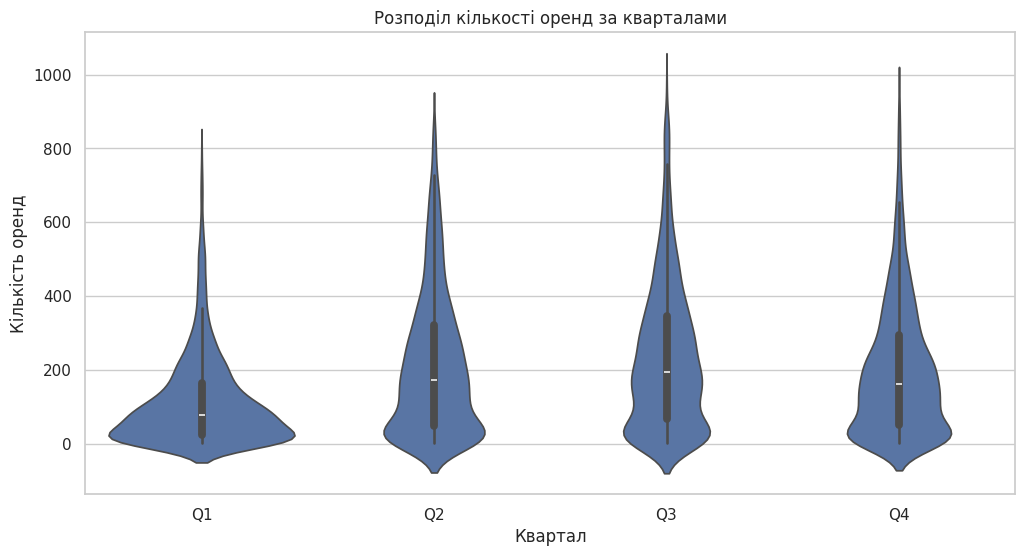

In [ ]:
sns.set_theme(
    style='whitegrid',
    rc={'figure.figsize': (12, 6)}                 # розмір графіка
)

ax = sns.violinplot(
    data=df,                                       # наш датафрейм
    x='quarter',                                   # квартали по осі X
    y='count',                                     # кількість оренд по осі Y
    order=['Q1', 'Q2', 'Q3', 'Q4']                 # правильний порядок кварталів
)

ax.set(
    title='Розподіл кількості оренд за кварталами',
    xlabel='Квартал',
    ylabel='Кількість оренд'
);

**Відповіді:**
1. *Що показує "товщина" violin plot?*


*   «Товщина» violin plot показує щільність розподілу значень. Чим ширша ділянка графіка на певному рівні, тим більше спостережень зосереджено біля цього значення кількості оренд. Вузькі ділянки навпаки, означають що такі значення зустрічаються рідше.



2. *В якому кварталі найбільша варіабельність оренди?*


*   Найбільша варіабельність спостерігається у III кварталі (Q3). Його violin plot має широкий розподіл і найбільший діапазон значень  від дуже низьких до понад 1000 оренд. Це означає, що протягом III кварталу кількість погодинних оренд змінювалася найбільш суттєво.



3. *Яка перевага violin plot над звичайним box plot?*


*   Box plot добре показує медіану, квартилі, розмах і викиди але не показує детальну форму розподілу. Violin plot додатково відображає щільність даних, тому видно, в яких діапазонах значення зустрічаються найчастіше та чи є кілька зон концентрації. Тобто, violin plot дає більш детальне уявлення про структуру розподілу ніж звичайний box plot.




## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

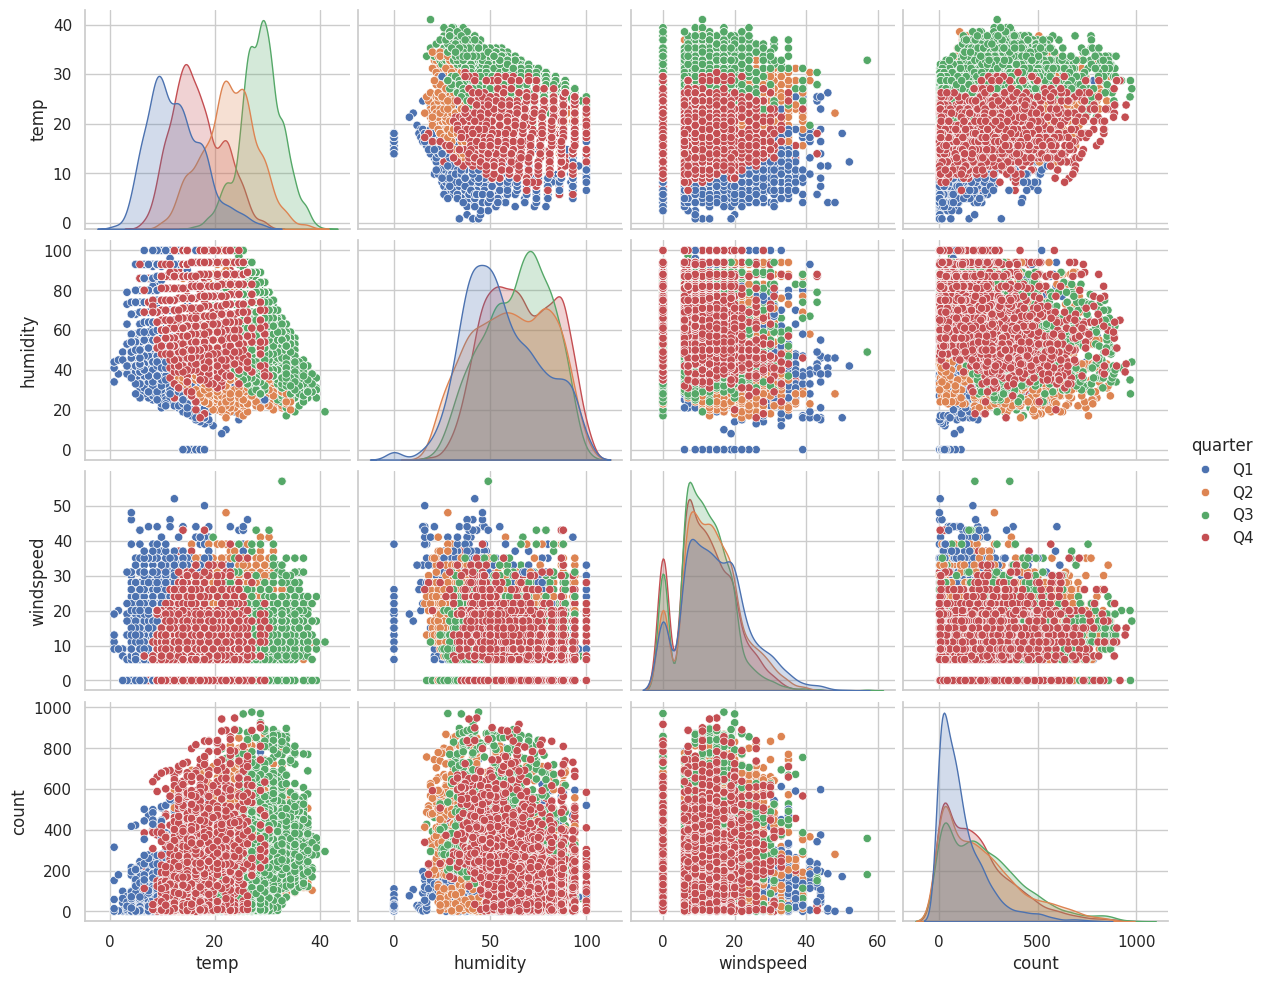

In [ ]:
# Вибираємо змінні для мультиваріативного аналізу
pair_data = df[['temp', 'humidity', 'windspeed', 'count', 'quarter']]

# Будуємо Pairplot з розбивкою за кварталами
sns.pairplot(
    data=pair_data,             # дані для побудови графіків
    hue='quarter',              # розбивка за кварталами різними кольорами
    height=2.5,                 # висота кожного окремого графіка
    aspect=1.2                  # співвідношення ширини до висоти
);

**Відповіді:**
1. *Між якими змінними спостерігається найсильніший лінійний зв'язок?*


*   Серед змінних temp, humidity, windspeed і count найпомітніший лінійний зв’язок спостерігається між температурою (temp) та кількістю оренд (count). За нашою кореляційною матрицею коефіцієнт кореляції між ними становить приблизно 0,39, тобто зв’язок позитивний, але помірний. Це означає, що зі зростанням температури кількість оренд у середньому також має тенденцію до збільшення, хоча на попит впливають і інші фактори.



2. *Яка характеристика найбільше відрізняється між кварталами?*


*   Найбільш помітно між кварталами відрізняється температура (temp). На pairplot точки різних кварталів за температурою розташовуються в різних діапазонах: для холодніших періодів характерні нижчі значення, а для тепліших кварталів  вищі. Це відповідає сезонності протягом року і одночасно частково пояснює різницю в кількості оренд між кварталами.




## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

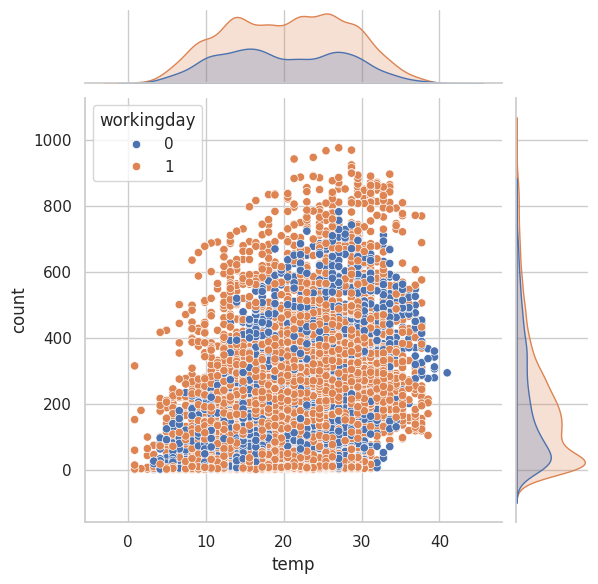

In [ ]:
# Будуємо Joint Plot для температури та кількості оренд
sns.jointplot(
    data=df,                 # наш датафрейм
    x='temp',                # температура по осі X
    y='count',               # кількість оренд по осі Y
    hue='workingday'         # розбивка: 0 - неробочий день, 1 - робочий день
);

**Відповідь:**
1. *Що показують графіки по краях?*


*  Графіки по краях joint plot показують окремі розподіли кожної змінної: зверху  розподіл температури (temp), з боку  розподіл кількості оренд (count). Вони дозволяють побачити в яких діапазонах температури та кількості оренд зосереджено найбільше спостережень. Завдяки параметру hue='workingday' також можна порівняти ці розподіли для робочих і неробочих днів.



2. *Чи є різниця у поведінці користувачів у робочий і неробочий день?*


*   Так різниця між робочими та неробочими днями спостерігається, хоча точки двох категорій значною мірою перекриваються. У робочі дні кількість оренд частіше концентрується в певних діапазонах, що може бути пов'язано з регулярними поїздками на роботу або навчання тоді як у неробочі дні попит може бути більш нерівномірним і залежати від температури та дозвілля. При цьому загальна тенденція зберігається для обох груп за вищої температури кількість оренд у середньому має тенденцію до зростання.


